In [6]:
!pip install openmeteo-requests requests-cache retry-requests pandas numpy lightgbm scikit-learn shap duckdb

   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 554.9/554.9 kB 1.9 MB/s  0:00:00
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   --- ------------------------------------ 1.0/13.2 MB 4.6 MB/s eta 0:00:03
   ---------- ----------------------------- 3.4/13.2 MB 6.9 MB/s eta 0:00:02
   ---------------- ----------------------- 5.5/13.2 MB 8.0 MB/s eta 0:00:01
   ----------------------- ---------------- 7.6/13.2 MB 8.4 MB/s eta 0:00:01
   -------------------------- ------------- 8.7/13.2 MB 8.3 MB/s eta 0:00:01
   ---------------------------- ----------- 9.4/13.2 MB 7.0 MB/s eta 0:00:01
   ------------------------------ --------- 10.0/13.2 MB 6.7 MB/s eta 0:00:01
   ------------------------------- -------- 10.5/13.2 MB 6.4 MB/s eta 0:00:01
   ----------------------------------- ---- 11.8/13.2 MB 6.0 MB/s eta 0:00:01
   ------------

In [11]:
import openmeteo_requests
import requests_cache
from retry_requests import retry
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. Setup Open-Meteo Client
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

LATITUDE = 33.6844
LONGITUDE = 73.0479

# Fetch past 1 year (365 days) of historical air quality data
today = datetime.now().date()
start_date = (today - timedelta(days=365)).strftime('%Y-%m-%d')
end_date = today.strftime('%Y-%m-%d')

print(f"Fetching historical backfill data from {start_date} to {end_date}...")

aq_url = "https://air-quality-api.open-meteo.com/v1/air-quality"
aq_params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": ["pm10", "pm2_5", "carbon_monoxide", "nitrogen_dioxide", "sulphur_dioxide", "ozone", "us_aqi"]
}

aq_response = openmeteo.weather_api(aq_url, params=aq_params)[0]
aq_hourly = aq_response.Hourly()

time_stamps = pd.date_range(
    start=pd.to_datetime(aq_hourly.Time(), unit="s", utc=True),
    end=pd.to_datetime(aq_hourly.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=aq_hourly.Interval()),
    inclusive="left"
)

df_aq = pd.DataFrame({
    "date_time": time_stamps,
    "pm10": aq_hourly.Variables(0).ValuesAsNumpy(),
    "pm2_5": aq_hourly.Variables(1).ValuesAsNumpy(),
    "co": aq_hourly.Variables(2).ValuesAsNumpy(),
    "no2": aq_hourly.Variables(3).ValuesAsNumpy(),
    "so2": aq_hourly.Variables(4).ValuesAsNumpy(),
    "ozone": aq_hourly.Variables(5).ValuesAsNumpy(),
    "us_aqi": aq_hourly.Variables(6).ValuesAsNumpy()
})

print(f"Total historical rows fetched: {len(df_aq)}")

# 2. Feature Engineering
df_features = df_aq.copy().sort_values("date_time").reset_index(drop=True)

df_features["hour"] = df_features["date_time"].dt.hour
df_features["day_of_week"] = df_features["date_time"].dt.dayofweek
df_features["month"] = df_features["date_time"].dt.month

df_features["aqi_lag_1h"] = df_features["us_aqi"].shift(1)
df_features["aqi_lag_3h"] = df_features["us_aqi"].shift(3)
df_features["aqi_lag_24h"] = df_features["us_aqi"].shift(24)
df_features["aqi_change_rate"] = df_features["us_aqi"] - df_features["aqi_lag_1h"]

# Target: AQI 24 hours into the future
df_features["target_aqi_24h"] = df_features["us_aqi"].shift(-24)

df_clean = df_features.dropna().reset_index(drop=True)
print(f"Clean features ready for training: {len(df_clean)} rows.")

# 3. Store in DuckDB Feature Store
import duckdb
conn = duckdb.connect('feature_store.duckdb')
conn.execute("CREATE OR REPLACE TABLE aqi_features AS SELECT * FROM df_clean")
conn.close()
print("Updated Feature Store with 1 year of historical data!")

Fetching historical backfill data from 2025-07-22 to 2026-07-22...
Total historical rows fetched: 8784
Clean features ready for training: 8736 rows.
Updated Feature Store with 1 year of historical data!


In [13]:
df_features = df_aq.copy().sort_values("date_time").reset_index(drop=True)

# 1. Temporal Features
df_features["hour"] = df_features["date_time"].dt.hour
df_features["day_of_week"] = df_features["date_time"].dt.dayofweek
df_features["month"] = df_features["date_time"].dt.month

# 2. Lag Features (AQI dynamics)
df_features["aqi_lag_1h"] = df_features["us_aqi"].shift(1)
df_features["aqi_lag_3h"] = df_features["us_aqi"].shift(3)
df_features["aqi_change_rate"] = df_features["us_aqi"] - df_features["aqi_lag_1h"]

# 3. Target (AQI 24 hours into the future)
df_features["target_aqi_24h"] = df_features["us_aqi"].shift(-24)

# Clean nulls
df_clean = df_features.dropna().reset_index(drop=True)

print("Processed Feature Set Preview:")
df_clean[['date_time', 'us_aqi', 'aqi_change_rate', 'target_aqi_24h']].head()

Processed Feature Set Preview:


,date_time,us_aqi,aqi_change_rate,target_aqi_24h
0,2025-07-22 03:00:00+00:00,86.438683,-1.973259,83.034584
1,2025-07-22 04:00:00+00:00,84.858482,-1.580200,82.704399
2,2025-07-22 05:00:00+00:00,83.867920,-0.990562,82.413521
3,2025-07-22 06:00:00+00:00,83.136787,-0.731133,81.792450
4,2025-07-22 07:00:00+00:00,82.036163,-1.100624,80.731133


In [14]:
import duckdb

# Connect to a local serverless Feature Store
conn = duckdb.connect('feature_store.duckdb')

# Register and store feature table
conn.execute("CREATE TABLE IF NOT EXISTS aqi_features AS SELECT * FROM df_clean")
print("Successfully written to DuckDB Feature Store!")

# Verify retrieval from Feature Store
stored_df = conn.execute("SELECT * FROM aqi_features").df()
conn.close()

print(f"Retrieved {len(stored_df)} feature rows from DuckDB.")

Successfully written to DuckDB Feature Store!
Retrieved 8736 feature rows from DuckDB.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000782 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2557
[LightGBM] [Info] Number of data points in the train set: 6988, number of used features: 13
[LightGBM] [Info] Start training from score 113.526450
--- Ridge Regression Performance ---
RMSE: 17.62
MAE:  13.44
R²:   0.7136

--- LightGBM Regressor Performance ---
RMSE: 19.03
MAE:  14.66
R²:   0.6658

Saved top-performing Ridge Regression model to 'model_registry/aqi_model.pkl'!


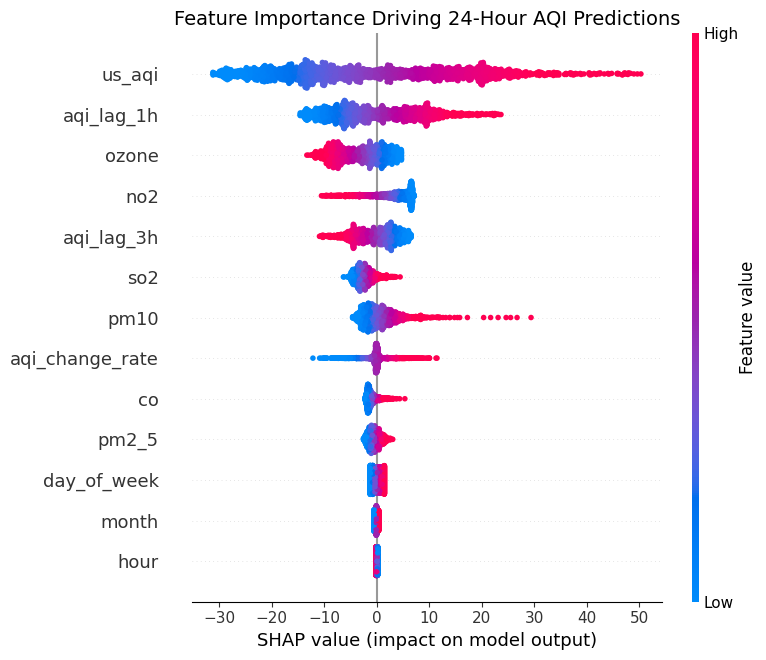

In [16]:
import duckdb
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
import lightgbm as lgb
import shap

# 1. Fetch training data from the DuckDB Feature Store
conn = duckdb.connect('feature_store.duckdb')
df = conn.execute("SELECT * FROM aqi_features").df()
conn.close()

# 2. Separate Features (X) and Target (y)
feature_cols = [
    'pm10', 'pm2_5', 'co', 'no2', 'so2', 'ozone', 'us_aqi',
    'hour', 'day_of_week', 'month', 'aqi_lag_1h', 'aqi_lag_3h', 'aqi_change_rate'
]
X = df[feature_cols]
y = df['target_aqi_24h']

# Split into 80% Train, 20% Test (chronological split is best for time-series)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 3. Train Baseline Model (Ridge Regression)
ridge_model = Ridge()
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# 4. Train Main Model (LightGBM)
lgb_model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

# 5. Evaluate Metrics
def evaluate_model(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} Performance ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R²:   {r2:.4f}\n")
    return {"rmse": rmse, "mae": mae, "r2": r2}

metrics_ridge = evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
metrics_lgb = evaluate_model(y_test, y_pred_lgb, "LightGBM Regressor")

import joblib
import os
import shap
import matplotlib.pyplot as plt

# 1. Save Ridge as our primary production model
os.makedirs("model_registry", exist_ok=True)
joblib.dump(ridge_model, "model_registry/aqi_model.pkl")
print("Saved top-performing Ridge Regression model to 'model_registry/aqi_model.pkl'!")

# 2. Compute SHAP values for Ridge Explanations
explainer = shap.LinearExplainer(ridge_model, X_train)
shap_values = explainer(X_test)

# Plot feature importance summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Feature Importance Driving 24-Hour AQI Predictions", fontsize=14)
plt.tight_layout()
plt.savefig("model_registry/shap_summary.png")
plt.show()

In [19]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import openmeteo_requests
import requests_cache
from retry_requests import retry
import plotly.graph_objects as go
import os

# Page Configuration
st.set_page_config(
    page_title="Pearls AQI Predictor",
    page_icon="🌫️",
    layout="wide"
)

# Title & Description
st.title("🌫️ Pearls Air Quality Index (AQI) Predictor")
st.markdown("Real-time air quality monitoring and **24-hour forecasting** powered by serverless ML.")

# 1. Load Model
@st.cache_resource
def load_model():
    model_path = "model_registry/aqi_model.pkl"
    if os.path.exists(model_path):
        return joblib.load(model_path)
    return None

model = load_model()

# 2. Fetch Live Data Function
@st.cache_data(ttl=1800)  # Refresh every 30 mins
def fetch_live_aqi():
    cache_session = requests_cache.CachedSession('.cache', expire_after=1800)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)

    LATITUDE = 33.6844   # Islamabad
    LONGITUDE = 73.0479

    aq_url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    aq_params = {
        "latitude": LATITUDE,
        "longitude": LONGITUDE,
        "hourly": ["pm10", "pm2_5", "carbon_monoxide", "nitrogen_dioxide", "sulphur_dioxide", "ozone", "us_aqi"],
        "forecast_days": 3
    }

    aq_response = openmeteo.weather_api(aq_url, params=aq_params)[0]
    aq_hourly = aq_response.Hourly()

    time_stamps = pd.date_range(
        start=pd.to_datetime(aq_hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(aq_hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=aq_hourly.Interval()),
        inclusive="left"
    )

    df_aq = pd.DataFrame({
        "date_time": time_stamps,
        "pm10": aq_hourly.Variables(0).ValuesAsNumpy(),
        "pm2_5": aq_hourly.Variables(1).ValuesAsNumpy(),
        "co": aq_hourly.Variables(2).ValuesAsNumpy(),
        "no2": aq_hourly.Variables(3).ValuesAsNumpy(),
        "so2": aq_hourly.Variables(4).ValuesAsNumpy(),
        "ozone": aq_hourly.Variables(5).ValuesAsNumpy(),
        "us_aqi": aq_hourly.Variables(6).ValuesAsNumpy()
    })
    return df_aq

# Helper for AQI Category & Colors
def get_aqi_status(aqi):
    if aqi <= 50:
        return "Good", "🟢", "#00e400"
    elif aqi <= 100:
        return "Moderate", "🟡", "#ffff00"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups", "🟠", "#ff7e00"
    elif aqi <= 200:
        return "Unhealthy", "🔴", "#ff0000"
    elif aqi <= 300:
        return "Very Unhealthy", "🟣", "#8f3f97"
    else:
        return "Hazardous", "🤎", "#7e0023"

# Main Logic
try:
    df_live = fetch_live_aqi()
    current_row = df_live.iloc[0]
    current_aqi = int(current_row['us_aqi'])
    status, emoji, color = get_aqi_status(current_aqi)

    # Top Metrics Bar
    col1, col2, col3, col4 = st.columns(4)
    with col1:
        st.metric(label="Current US AQI", value=f"{current_aqi} {emoji}")
    with col2:
        st.metric(label="AQI Category", value=status)
    with col3:
        st.metric(label="PM2.5", value=f"{current_row['pm2_5']:.1f} µg/m³")
    with col4:
        st.metric(label="PM10", value=f"{current_row['pm10']:.1f} µg/m³")

    st.divider()

    # Predict Future AQI
    if model is not None:
        # Prepare feature vector for prediction matching exact training columns
        df_feat = df_live.copy()
        df_feat["hour"] = df_feat["date_time"].dt.hour
        df_feat["day_of_week"] = df_feat["date_time"].dt.dayofweek
        df_feat["month"] = df_feat["date_time"].dt.month
        df_feat["aqi_lag_1h"] = df_feat["us_aqi"].shift(1).fillna(current_aqi)
        df_feat["aqi_lag_3h"] = df_feat["us_aqi"].shift(3).fillna(current_aqi)
        df_feat["aqi_change_rate"] = df_feat["us_aqi"] - df_feat["aqi_lag_1h"]

        feature_cols = [
            'pm10', 'pm2_5', 'co', 'no2', 'so2', 'ozone', 'us_aqi',
            'hour', 'day_of_week', 'month', 'aqi_lag_1h', 'aqi_lag_3h', 'aqi_change_rate'
        ]

        predicted_aqi = int(model.predict(df_feat[feature_cols].iloc[[0]])[0])
        pred_status, pred_emoji, _ = get_aqi_status(predicted_aqi)

        st.subheader("🤖 Model Forecast (Next 24 Hours)")
        st.info(f"Forecasted AQI for tomorrow: **{predicted_aqi} ({pred_status} {pred_emoji})**")

        # Alert Banner for High AQI
        if predicted_aqi > 150:
            st.error(f"🚨 **HAZARDOUS AIR QUALITY ALERT:** The forecasted AQI is **{predicted_aqi}**. Sensitive individuals and outdoor activities should be limited!")

    # Interactive Trend Plot
    st.subheader("📈 3-Day Air Quality Trend")
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=df_live['date_time'], 
        y=df_live['us_aqi'],
        mode='lines+markers',
        name='Hourly AQI',
        line=dict(color='#1f77b4', width=3)
    ))
    fig.update_layout(
        xaxis_title="Time",
        yaxis_title="US AQI Index",
        hovermode="x unified",
        margin=dict(l=20, r=20, t=30, b=20)
    )
    st.plotly_chart(fig, use_container_width=True)

    # Feature Importance Section
    if os.path.exists("model_registry/shap_summary.png"):
        st.divider()
        st.subheader("💡 Model Explainability (SHAP Importance)")
        st.image("model_registry/shap_summary.png", caption="Key features influencing AQI predictions", use_column_width=True)

except Exception as e:
    st.error(f"Error loading dashboard data: {e}")

Overwriting app.py


In [18]:
!pip install streamlit plotly